In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
import os

In [ ]:
bikes_df = pd.read_csv("./bikes/hour.csv")
bikes_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


One observation per recorded hour. Combined `dteday` and `hr` to obtain the
timestamp. 

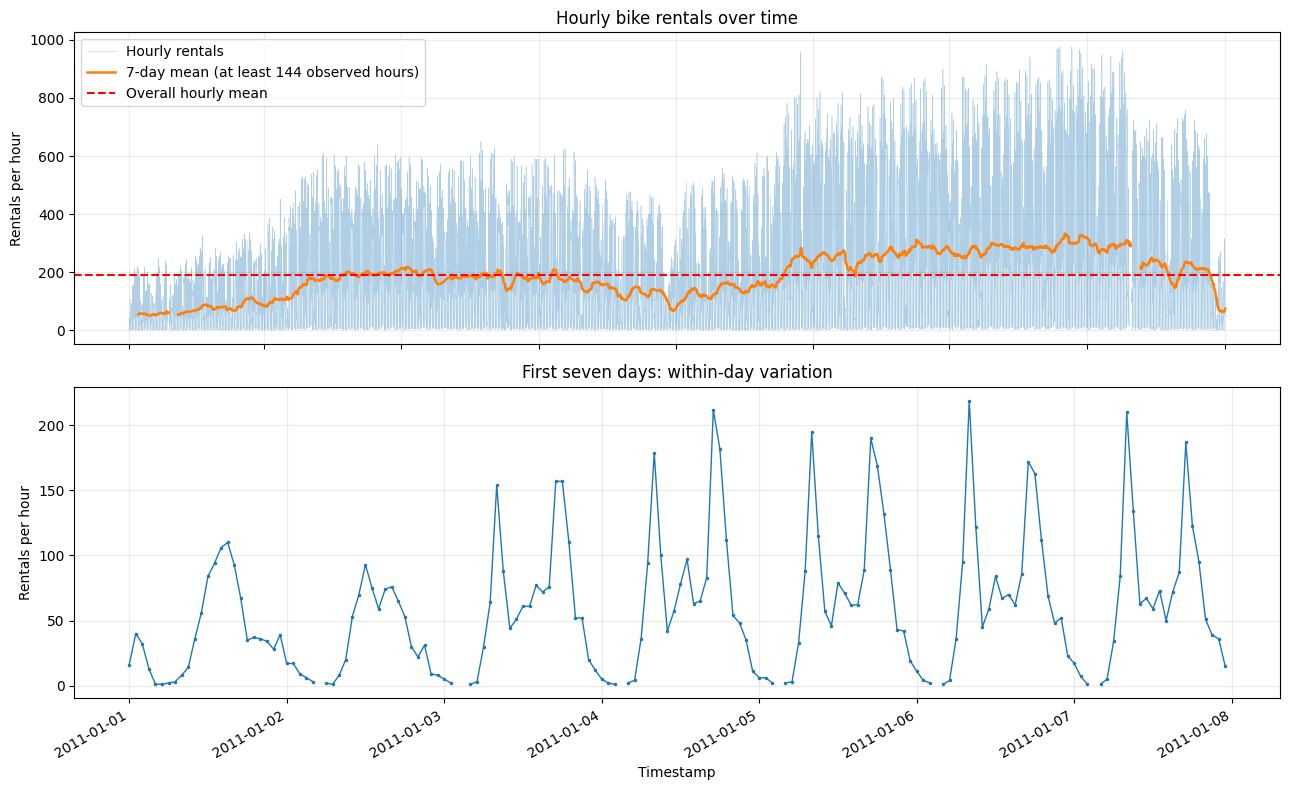

In [ ]:
bikes_df['date'] = (pd.to_datetime(bikes_df['dteday'])
                    + pd.to_timedelta(bikes_df['hr'], unit='h'))
df1 = bikes_df.sort_values('date').copy()
assert df1['date'].is_unique, 'Resolve duplicate hourly timestamps.'
hourly_counts = df1.set_index('date')['cnt'].asfreq('h')
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
axes[0].plot(hourly_counts.index, hourly_counts, linewidth=0.4,
             alpha=0.35, label='Hourly rentals')
axes[0].plot(hourly_counts.rolling('7D', min_periods=144).mean(),
             color='tab:orange', linewidth=1.8, label='7-day mean (at least 144 observed hours)')
axes[0].axhline(hourly_counts.mean(), color='red', linestyle='--', label='Overall hourly mean')
axes[0].set(title='Hourly bike rentals over time', xlabel='Date', ylabel='Rentals per hour')
week_start = hourly_counts.index.min()
week = hourly_counts.loc[(hourly_counts.index >= week_start)
                         & (hourly_counts.index < week_start + pd.Timedelta(days=7))]
axes[1].plot(week.index, week, linewidth=1, marker='.', markersize=3)
axes[1].set(title='First seven days: within-day variation', xlabel='Timestamp', ylabel='Rentals per hour')
for ax in axes:
    ax.grid(alpha=0.25)
axes[0].legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

Looks like hour-of-day might be a useful metric for signal to demand

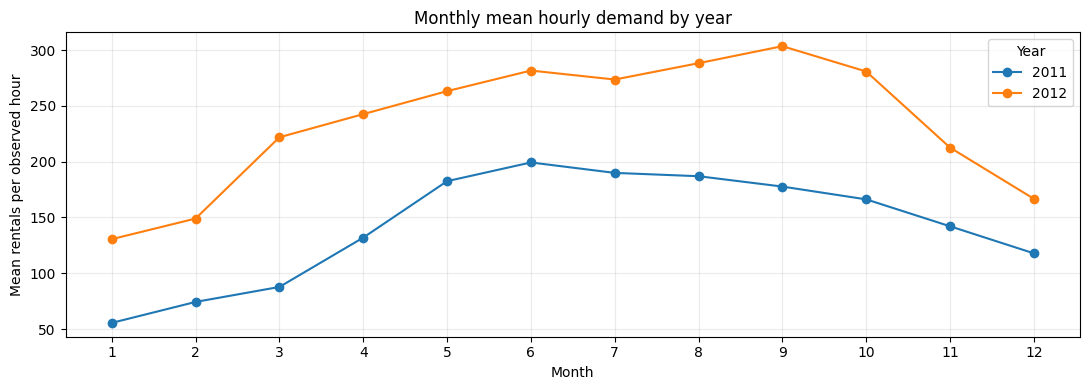

In [ ]:
monthly_means = df1.groupby([df1['date'].dt.year, 'mnth'])['cnt'].mean().unstack(0)
ax = monthly_means.plot(marker='o', figsize=(11, 4))
ax.set(title='Monthly mean hourly demand by year', xlabel='Month',
       ylabel='Mean rentals per observed hour', xticks=range(1, 13))
ax.legend(title='Year')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Over the two years, there is clearly a `seasonal` trend. Since the data is from Washington, USA, summer season (mid-year) tends to record higher bike counts.

## Exploratory analysis of hourly bike counts

`casual` and `registered` are excluded from predictor plots because their sum is `cnt`

using their target-hour values would leak the target

In [ ]:
import numpy as np
from IPython.display import display

eda = df1.set_index('date').copy()
eda['year'] = eda.index.year
eda['quarter'] = eda.index.to_period('Q').astype(str)
print(f'{len(eda):,} recorded hours; {hourly_counts.isna().sum():,} missing hours '
      'between the first and last timestamp.')
display(eda.groupby('year')['cnt'].agg(['count', 'mean', 'std', 'min', 'max']).round(1))

17,379 recorded hours; 165 missing hours between the first and last timestamp.


,count,mean,std,min,max
year,,,,,
2011,8645,143.8,133.8,1,651
2012,8734,234.7,208.9,1,977


Not every chornoligical timestamp is present. Will have to consider perhaps splitting sequences here. Cannot expect to train model on fixed sequence single timesteps and predict a gap/jump

Also, clearly second year more demand

### Hour-of-day and weekday patterns
Compare working days with weekends/holidays, and inspect the weekly demand profile.
Values are mean rentals per observed hour.

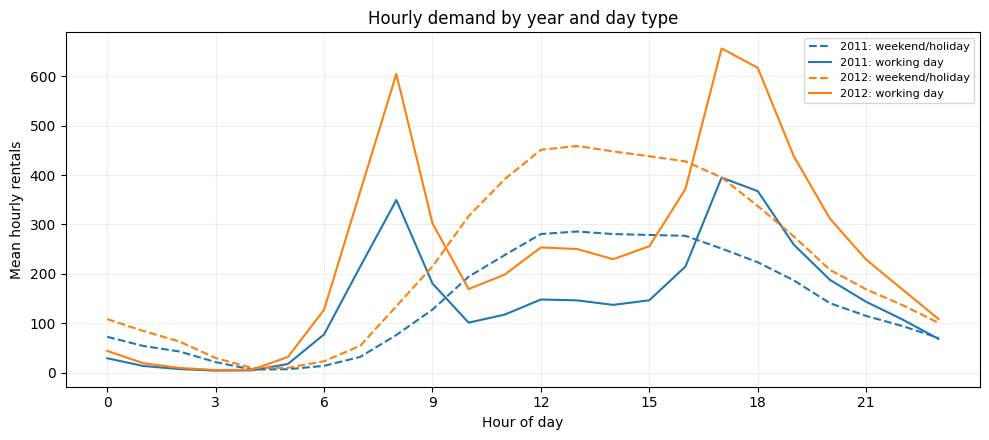

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))

for (year, workingday), group in eda.groupby(["year", "workingday"]):
  profile = group.groupby("hr")["cnt"].mean().reindex(range(24))
  day_type = "working day" if workingday else "weekend/holiday"

  ax.plot(
      profile.index,
      profile,
      label=f"{year}: {day_type}",
      linestyle="-" if workingday else "--",
      color="tab:blue" if year == 2011 else "tab:orange",
  )

ax.set(
    title="Hourly demand by year and day type",
    xlabel="Hour of day",
    ylabel="Mean hourly rentals",
    xticks=range(0, 24, 3),
)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

Seems to be more popularity in year 2 -> non-stationarity

In weekdays clear morning and evening demand high

Weekends/holiday peak midday

### Continuous features and the target
Color separates the years so that changes in demand level are visible at similar feature values.


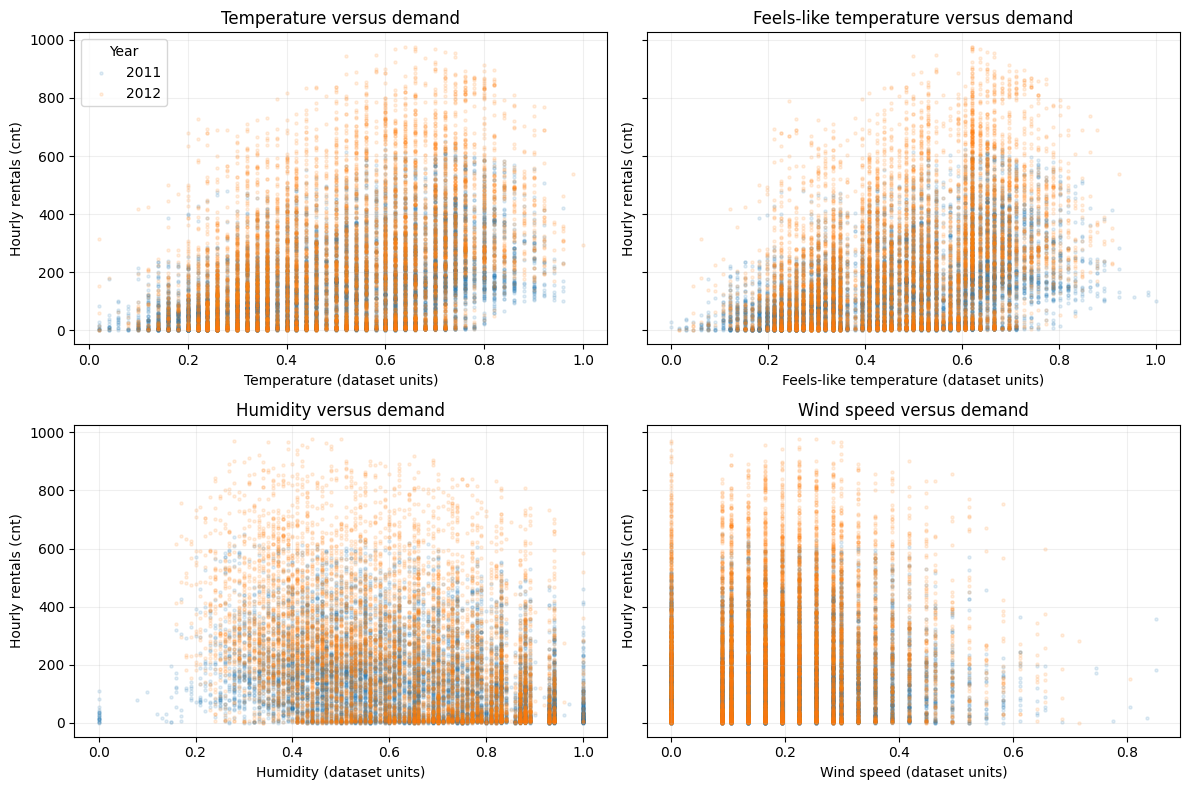

In [ ]:
features = {'temp': 'Temperature', 'atemp': 'Feels-like temperature',
            'hum': 'Humidity', 'windspeed': 'Wind speed'}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, (feature, label) in zip(axes.flat, features.items()):
    for year, group in eda.groupby('year'):
        ax.scatter(group[feature], group['cnt'], s=5, alpha=0.12, rasterized=True, label=str(year))
    ax.set(xlabel=f'{label} (dataset units)', ylabel='Hourly rentals (cnt)',
           title=f'{label} versus demand')
    ax.grid(alpha=0.2)
axes[0, 0].legend(title='Year')
fig.tight_layout()
plt.show()

The scatter plots show marginal associations at hourly rates. 

Seems like positive relation between temp and demand. But not stationary -> changes for different year

### Distribution changes through time


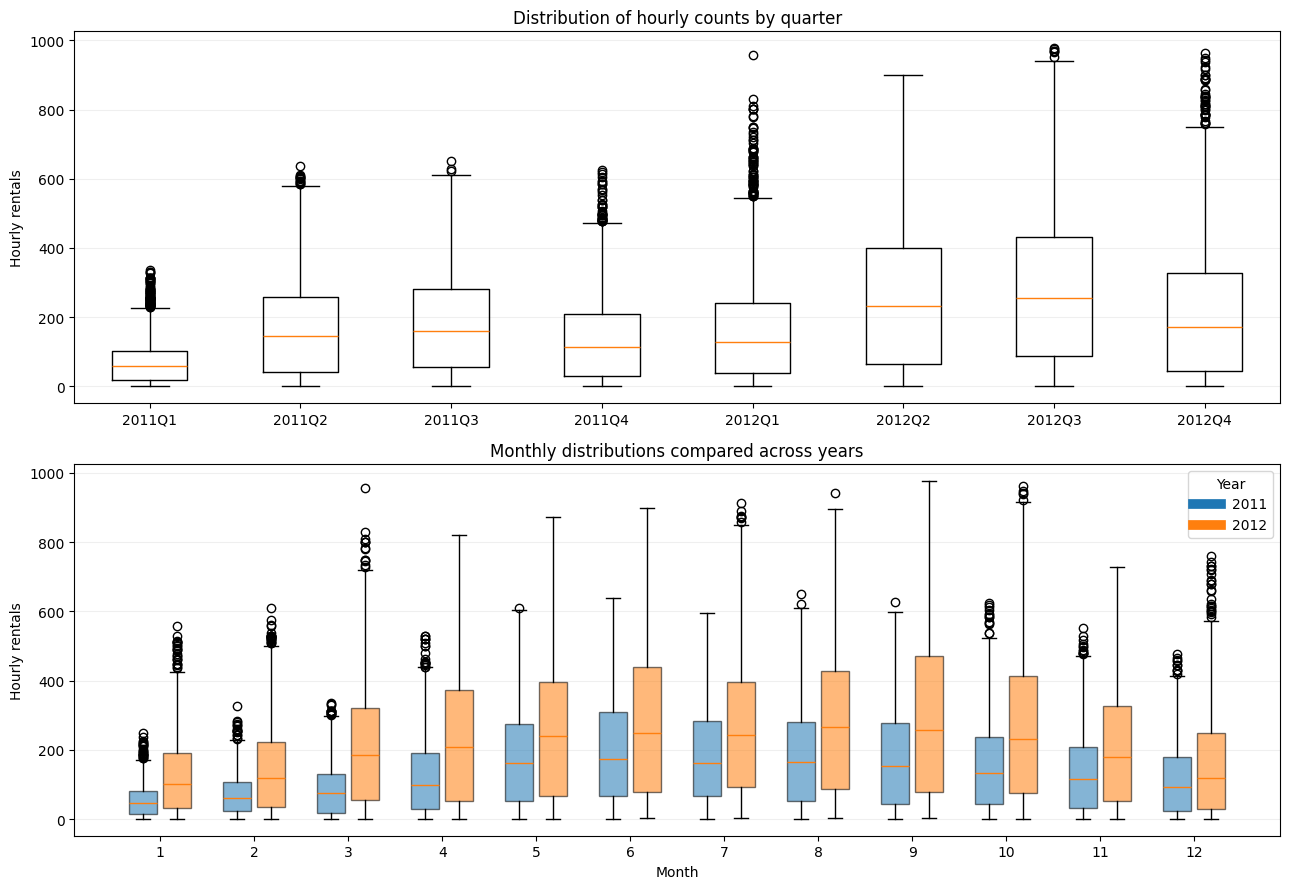

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
quarters = sorted(eda['quarter'].unique())
axes[0].boxplot([eda.loc[eda['quarter'].eq(q), 'cnt'] for q in quarters])
axes[0].set_xticks(range(1, len(quarters) + 1), quarters)
axes[0].set(title='Distribution of hourly counts by quarter', ylabel='Hourly rentals')
for year, offset, color in [(2011, -0.18, 'tab:blue'), (2012, 0.18, 'tab:orange')]:
    groups = [eda.loc[eda['year'].eq(year) & eda['mnth'].eq(m), 'cnt'] for m in range(1, 13)]
    boxes = axes[1].boxplot(groups, positions=np.arange(1, 13) + offset,
                            widths=0.30, patch_artist=True, manage_ticks=False)
    for box in boxes['boxes']:
        box.set(facecolor=color, alpha=0.55)
    axes[1].plot([], [], color=color, linewidth=7, label=str(year))
axes[1].set(xticks=range(1, 13), xlabel='Month', ylabel='Hourly rentals',
            title='Monthly distributions compared across years')
axes[1].legend(title='Year')
for ax in axes:
    ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()

### Is the raw hourly series stationary?
Stationarity requires a constant mean and variance.

The 30-day rolling mean and standard deviation below smooth the within-day and
within-week cycles.

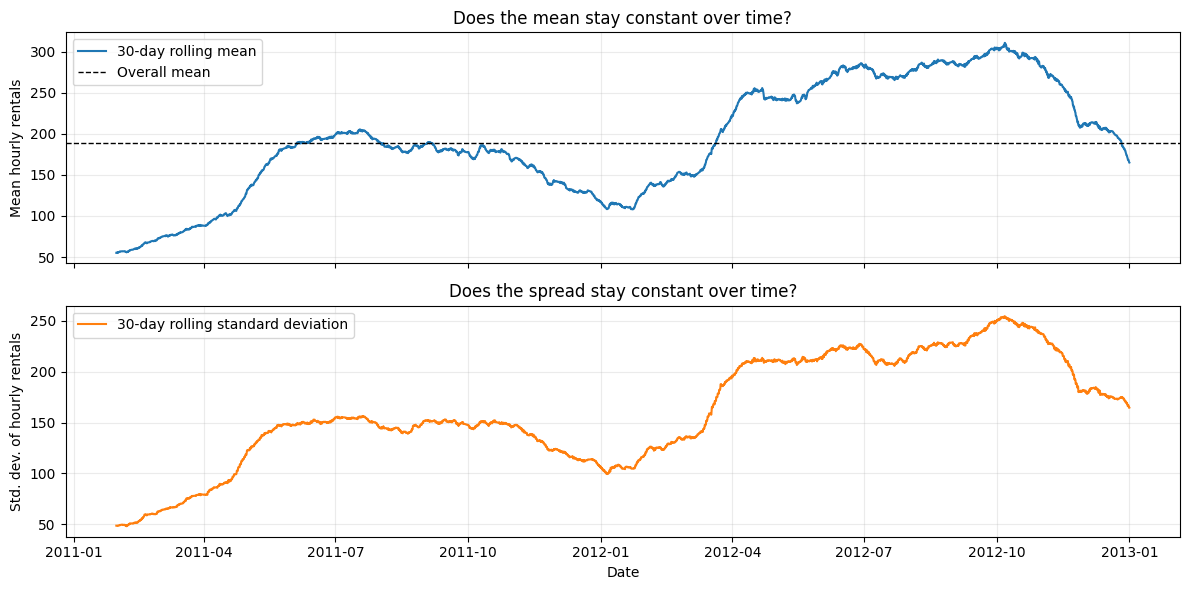

,Mean hourly rentals,Std. dev. of hourly rentals
year,,
2011,143.8,133.8
2012,234.7,208.9


In [26]:
rolling_counts = hourly_counts.rolling('30D', min_periods=648)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(rolling_counts.mean(), color='tab:blue', label='30-day rolling mean')
axes[0].axhline(hourly_counts.mean(), color='black', linestyle='--',
                linewidth=1, label='Overall mean')
axes[0].set(title='Does the mean stay constant over time?', ylabel='Mean hourly rentals')
axes[1].plot(rolling_counts.std(), color='tab:orange', label='30-day rolling standard deviation')
axes[1].set(title='Does the spread stay constant over time?',
            ylabel='Std. dev. of hourly rentals', xlabel='Date')
for ax in axes:
    ax.legend(loc='upper left')
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

year_summary = eda.groupby('year')['cnt'].agg(['mean', 'std']).round(1)
display(year_summary.rename(columns={'mean': 'Mean hourly rentals',
                                     'std': 'Std. dev. of hourly rentals'}))
matched_months = eda.groupby(['mnth', 'year'])['cnt'].mean().unstack('year')


### Conclusion: there is evidence of non-stationarity


1. **Changing mean:** the rolling mean and matched-month/year comparison show whether
   demand has a stable level. A consistently higher level in 2012 than in the same
   months of 2011 supports non-stationary distribution

2. **Changing spread:** sustained differences in rolling standard deviation suggest
   changing variability


The changing demand level is the main reason to treat the raw hourly counts as
non-stationary

### Hourly differences
Change from the previous hour: `cnt(t) - cnt(t-1)`

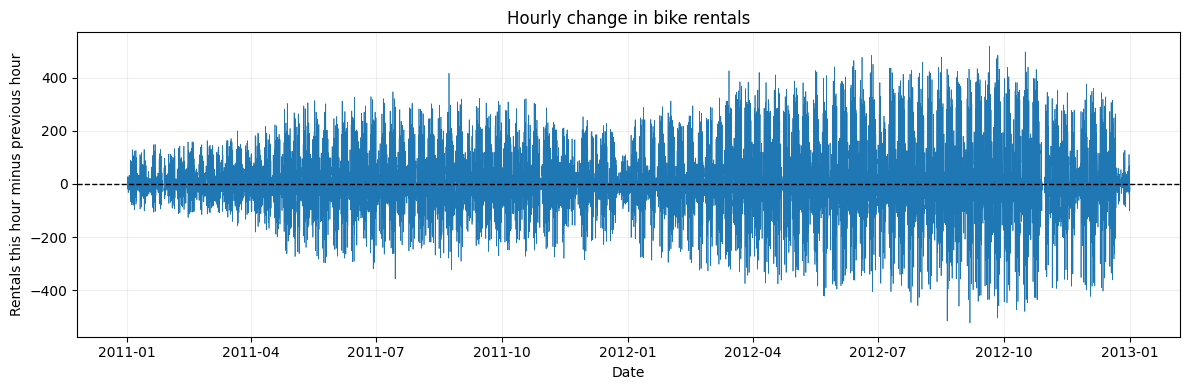

In [ ]:
hourly_difference = hourly_counts.diff()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_difference.index, hourly_difference, linewidth=0.5, color='tab:blue')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set(title='Hourly change in bike rentals', xlabel='Date',
       ylabel='Rentals this hour minus previous hour')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

More fixed in time/stationary hourly demand differences -> possibility for predicting difference at time t and add to cnt(t-1) to get prediction. This will enable us to train on non-temporally changing data

Variables to consider:

`hr`, `weekday`. (`mnth` or `season` - one, carry similar information) to encode cyclically

`workingday`, `holiday`

`temp`, `hum`, `windspeed`

`cnt` t-1

`yr` if training and pred includes both years so no extrapolation

but no generliasaiton to future years

since stationarity very much tied to yr, including it helps model explain changing level

In [21]:
df2 = pd.read_csv("./appliances/energydata_complete.csv")
df3 = pd.read_csv("./climate_data/jena_climate_2009_2016.csv")
df4 = pd.read_csv("./sunspots/SN_d_tot_V2.0.csv")
df5 = pd.read_csv("./Unemployment_rate/UNRATE.csv")

Jena is massive, selected reduced 2014-2016 period
Comes in 10-minute readings -> will change to hourly to reduce training time